In [1]:
'''Energydetection, updated Mar2023
'''
import torch
import os
#os.environ["CUDA_VISIBLE_DEVICES"]="0"
import math
import torchvision
import torchvision.transforms as transforms
import torch.utils.data.distributed as TUDdistributed
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.autograd import Variable
import sys
from copy import deepcopy
import random
import collections
#from MobileNetV1_CriticalPath import Net
import matplotlib.pyplot as plt
import pandas as pd 
# from sklearn.externals import joblib
from cnn_models import standalone_cnn
from cnn_models import decouple_cnn
from cnn_models import decouple_cnn_mod

from pytz import timezone
TMZ = timezone('EST')
import datetime
import shutil
import time

device = torch.device("cuda")
use_cuda = True
criterion = nn.CrossEntropyLoss()

random.seed(0) 

      

def Dis_analysis(class_dir, tol_list):
  #idx_list: list of lists, global positions of locally observable bands for each node
  #coef_list: coef for averaging the param for each band, how many nodes are learning each certain band
    idx_list = []
    coef_list = [0]*len( tol_list )
    for i in range( len(class_dir) ): #Generating the mapping btw nodes and net_tol
        sub_idx_list = [] 
        for j in class_dir[i]:
            for k in range( len(tol_list) ):
                if j == tol_list[k]:
                    sub_idx_list.append(k)
                    coef_list[k] += 1 
                    break
        idx_list.append(sub_idx_list)
    return idx_list, coef_list


"""626/720 dataset maker, each logit corresponds to the occupation of a single channel"""
class TotalDatasetMaker(Dataset):
    "simple version that requires the user to edit input/label format elsewhere"
    def __init__(self, db, label_list, transformFunc ):
        """
        db: a list of input signal tensors, label_list: a list of data labels, corresponding to db.
        """
        self.datasets = db
        self.label_list = label_list
        self.transformFunc = transformFunc
    def __getitem__(self, i):
        img = self.datasets[i]
        img = self.transformFunc(img)
        class_label = self.label_list[i]
        return img, class_label

    def __len__(self):
        return len(self.label_list)
    
    
"""720 dataset maker, data looks like: each global channel occupation condition ==> 
each node only learn from 'local' received signal(full size for each node) which is an element in the list of this condition """
class NodeDatasetMaker(Dataset):

    def __init__(self, db, label_list, node, class_dir, transformFunc ):
        """
        db: a list of input signal tensors, label_list: a list of data labels, corresponding to db.
        node
        """
        self.datasets = db
        self.label_list = label_list
        self.transformFunc = transformFunc
        self.chn_list = class_dir[node]
        self.node = node
    def __getitem__(self, i):
        img = self.datasets[i][self.node]
        img = self.transformFunc(img)
        class_label = self.label_list[i][self.chn_list]
        return img, class_label

    def __len__(self):
        return len(self.label_list)

def setDir(filepath):
  # if directory not exist, create. if directory already exist, empty it.
  if not os.path.exists(filepath):
    os.makedirs(filepath)
  else:
    print('Directory already exists')
    shutil.rmtree(filepath, ignore_errors = True)
    os.mkdir(filepath)
       
print('start')

start


In [2]:
def energy_detection_coop(thresh_list, class_dir, coef_list, test_loader):                             
#     '''Tests all nodes together, use TotalDatasetMaker, smarter distrib energy detection'''
#     '''thresh_list is the thresh for diff nodes, by default they're the same'''
    total = 0 #sum of occupation and emptiness
    test_loss = 0 
    total_ocp = 0 #occupied bands
    total_emp = 0 #empty bands
    correct = 0
    total_cmb = 0  #occupation combination
    correct_ocp = 0
    correct_emp = 0
    correct_cmb = 0
    coef = torch.tensor(coef_list)

    for batchidx, (data, target) in enumerate(test_loader):
        #data, target = data.cuda(), target.cuda()
        #print(target.size())
#             data, target = Variable(data), Variable(target)
        target = Variable(target)
#             print('target size is:',target.size())
        output_manual = torch.zeros(target.shape) # manual global decision of CNN
        total_batch = float(torch.tensor(target.size()).prod()) #total num of channels in this batch
        total += total_batch
        total_cmb += float(target.size(0))
        total_ocp += float(target.sum())
        total_emp += float(total_batch - target.sum()) 
        if (1-target).sum() != (torch.tensor(target.size()).prod() - target.sum()) : #Testing tensor dim =========
            print('show difference:',(1-target).sum(), total - target.sum())
            print('total ocp/emp calculation wrong')
        '''Above calculate the total number of channels detected and the ground truth number of occupation/emptiness'''

        for idx in range(len(class_dir)): # apply fusion strategy on local detections
            node_power = torch.sum(1e7*data[idx], dim = -2)#  # get (batchsize*2) tensors of local channel power
            if idx == -1:
                print(node_power)
            localout = (node_power[:,0,class_dir[idx]]>thresh_list[idx]).float()
            output_manual[:,class_dir[idx]] = output_manual[:,class_dir[idx]].add(localout) 
            # strategy: any node detects means occupation

        output_manual = (output_manual.div_(coef) >0.49)
        correct_ocp += (output_manual*target).sum()
        correct_emp += ((~output_manual)*(1-target)).sum()
        correct_cmb += (~(output_manual^target.bool())).float().prod(1).sum() #use XNOR which is 'not+XOR'
#         print('correctocp',correct_ocp)

    correct_tol = deepcopy(correct_ocp) + deepcopy(correct_emp) #just sum
    accuracy_tol = 100*correct_tol/total
    accuracy_pd = 100*correct_ocp/total_ocp
    accuracy_pfa = 100*correct_emp/total_emp
    accuracy_cmb = 100*correct_cmb/total_cmb

#     print('++++++++++++++++++ Accuracy on global set: total: %d %%, combination: %d %%, PD: %d %%, PFA: %d %%' \
#                                             % ( accuracy_tol, accuracy_cmb, accuracy_pd, 100-accuracy_pfa))
    Acc_set = (accuracy_tol.item(), accuracy_cmb.item(), accuracy_pd.item(), 100-accuracy_pfa.item())
    return Acc_set

# ''' for energy detection'''
def energy_detection_coopSQR(thresh_list, class_dir, coef_list, test_loader):  
# squared input PSD                           
#     '''Tests all nodes together, use TotalDatasetMaker, smarter distrib energy detection'''
#     '''thresh_list is the thresh for diff nodes, by default they're the same'''
    total = 0 #sum of occupation and emptiness
    test_loss = 0 
    total_ocp = 0 #occupied bands
    total_emp = 0 #empty bands
    correct = 0
    total_cmb = 0  #occupation combination
    correct_ocp = 0
    correct_emp = 0
    correct_cmb = 0
    coef = torch.tensor(coef_list)
    for batchidx, (data, target) in enumerate(test_loader):
        #data, target = data.cuda(), target.cuda()
        #print(target.size())
#             data, target = Variable(data), Variable(target)
        target = Variable(target)
#             print('target size is:',target.size())
        output_manual = torch.zeros(target.shape) # manual global decision of CNN
        total_batch = float(torch.tensor(target.size()).prod()) #total num of channels in this batch
        total += total_batch
        total_cmb += float(target.size(0))
        total_ocp += float(target.sum())
        total_emp += float(total_batch - target.sum()) 
        if (1-target).sum() != (torch.tensor(target.size()).prod() - target.sum()) : #Testing tensor dim =========
            print('show difference:',(1-target).sum(), total - target.sum())
            print('total ocp/emp calculation wrong')
        '''Above calculate the total number of channels detected and the ground truth number of occupation/emptiness'''
        for idx in range(len(class_dir)): # apply fusion strategy on local detections
            node_power = torch.sum((1e7*data[idx])**2, dim = -2)#  # get (batchsize*2) tensors of local channel power
            if idx == -1:
                print(node_power)
            localout = (node_power[:,0,class_dir[idx]]>thresh_list[idx]).float()
            output_manual[:,class_dir[idx]] = output_manual[:,class_dir[idx]].add(localout) 
            # strategy: any node detects means occupation
        output_manual = (output_manual.div_(coef) >0.49)
        correct_ocp += (output_manual*target).sum()
        correct_emp += ((~output_manual)*(1-target)).sum()
        correct_cmb += (~(output_manual^target.bool())).float().prod(1).sum() #use XNOR which is 'not+XOR'
#         print('correctocp',correct_ocp)
    correct_tol = deepcopy(correct_ocp) + deepcopy(correct_emp) #just sum
    accuracy_tol = 100*correct_tol/total
    accuracy_pd = 100*correct_ocp/total_ocp
    accuracy_pfa = 100*correct_emp/total_emp
    accuracy_cmb = 100*correct_cmb/total_cmb
#     print('++++++++++++++++++ Accuracy on global set: total: %d %%, combination: %d %%, PD: %d %%, PFA: %d %%' \                                          % ( accuracy_tol, accuracy_cmb, accuracy_pd, 100-accuracy_pfa))
    Acc_set = (accuracy_tol.item(), accuracy_cmb.item(), accuracy_pd.item(), 100-accuracy_pfa.item())
    return Acc_set

def ROC_thresh(start, end, pts):
    return [start+i*(end-start)/pts for i in range(100)]

thresh_dict = {
    0: ROC_thresh(10, 30 ,100),
    -2: ROC_thresh(15, 40 ,100),
    -4: ROC_thresh(20, 50 ,100),
    -6: ROC_thresh(40, 80 ,100),
    -8: ROC_thresh(70, 120 ,100),
    -10: ROC_thresh(100, 200 ,100),
    -12: ROC_thresh(170, 300 ,100),
    -14: ROC_thresh(300, 460 ,100),
    -16: ROC_thresh(450, 700 ,100),
    -18: ROC_thresh(450, 700 ,100),
}


/tmp/ipykernel_2444337/2615564119.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load(datadir)


[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]] [2, 3, 2, 2, 6, 6, 2, 2, 3, 2, 3, 2, 2, 6, 2, 2, 3, 2, 2, 6]
model watermark 260511_14_03
Models saved to dir:
 Saved_Models/EnergyDetect/RandMod/0dBVol10_260511_14_03/
threshold: 10.0
thresh: 10.0 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 10.2
thresh: 10.2 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 10.4
thresh: 10.4 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 10.6
thresh: 10.6 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 10.8
thresh: 10.8 accuracy:

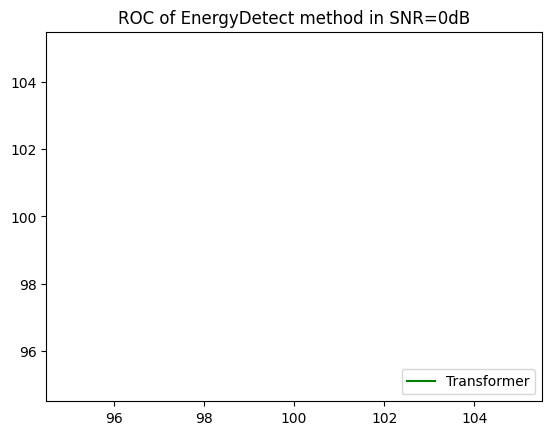

ROC in Excel saved to: Saved_Models/EnergyDetect/RandMod/0dBVol10_260511_14_03/ROC_SNR0.xlsx
ROC in Lists saved to: Saved_Models/EnergyDetect/RandMod/0dBVol10_260511_14_03/EnergyDetectROC.pth


/tmp/ipykernel_2444337/2615564119.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load(datadir)


[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]] [2, 3, 2, 2, 6, 6, 2, 2, 3, 2, 3, 2, 2, 6, 2, 2, 3, 2, 2, 6]
model watermark 260511_14_07
Models saved to dir:
 Saved_Models/EnergyDetect/RandMod/-2dBVol10_260511_14_07/
threshold: 15.0
thresh: 15.0 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 15.25
thresh: 15.25 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 15.5
thresh: 15.5 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 15.75
thresh: 15.75 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 16.0
thresh: 16.0 accu

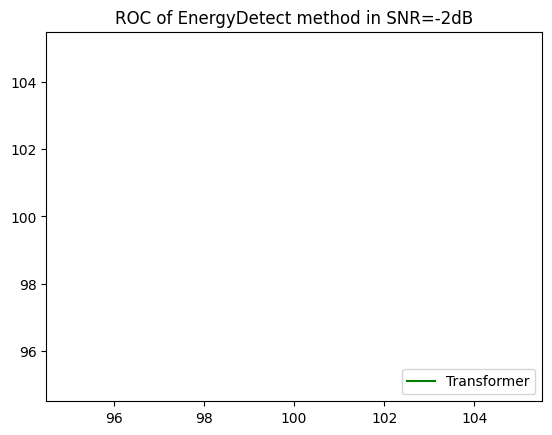

ROC in Excel saved to: Saved_Models/EnergyDetect/RandMod/-2dBVol10_260511_14_07/ROC_SNR-2.xlsx
ROC in Lists saved to: Saved_Models/EnergyDetect/RandMod/-2dBVol10_260511_14_07/EnergyDetectROC.pth


/tmp/ipykernel_2444337/2615564119.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load(datadir)


[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]] [2, 3, 2, 2, 6, 6, 2, 2, 3, 2, 3, 2, 2, 6, 2, 2, 3, 2, 2, 6]
model watermark 260511_14_08
Models saved to dir:
 Saved_Models/EnergyDetect/RandMod/-4dBVol10_260511_14_08/
threshold: 20.0
thresh: 20.0 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 20.3
thresh: 20.3 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 20.6
thresh: 20.6 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 20.9
thresh: 20.9 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 21.2
thresh: 21.2 accuracy

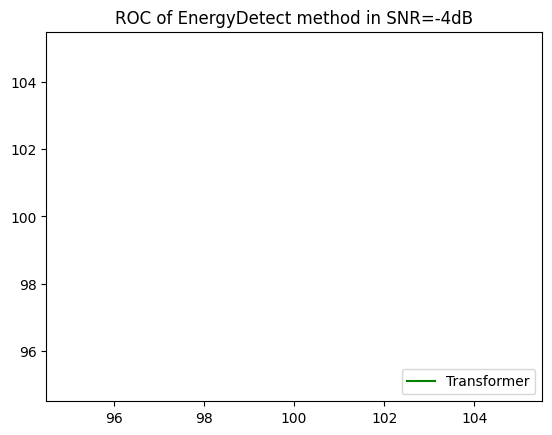

ROC in Excel saved to: Saved_Models/EnergyDetect/RandMod/-4dBVol10_260511_14_08/ROC_SNR-4.xlsx
ROC in Lists saved to: Saved_Models/EnergyDetect/RandMod/-4dBVol10_260511_14_08/EnergyDetectROC.pth


/tmp/ipykernel_2444337/2615564119.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load(datadir)


[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]] [2, 3, 2, 2, 6, 6, 2, 2, 3, 2, 3, 2, 2, 6, 2, 2, 3, 2, 2, 6]
model watermark 260511_14_12
Models saved to dir:
 Saved_Models/EnergyDetect/RandMod/-6dBVol10_260511_14_12/
threshold: 40.0
thresh: 40.0 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 40.4
thresh: 40.4 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 40.8
thresh: 40.8 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 41.2
thresh: 41.2 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 41.6
thresh: 41.6 accuracy

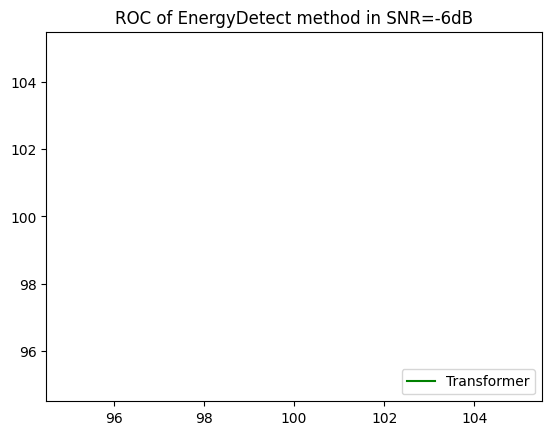

ROC in Excel saved to: Saved_Models/EnergyDetect/RandMod/-6dBVol10_260511_14_12/ROC_SNR-6.xlsx
ROC in Lists saved to: Saved_Models/EnergyDetect/RandMod/-6dBVol10_260511_14_12/EnergyDetectROC.pth


/tmp/ipykernel_2444337/2615564119.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load(datadir)


[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]] [2, 3, 2, 2, 6, 6, 2, 2, 3, 2, 3, 2, 2, 6, 2, 2, 3, 2, 2, 6]
model watermark 260511_14_13
Models saved to dir:
 Saved_Models/EnergyDetect/RandMod/-8dBVol10_260511_14_13/
threshold: 70.0
thresh: 70.0 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 70.5
thresh: 70.5 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 71.0
thresh: 71.0 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 71.5
thresh: 71.5 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 72.0
thresh: 72.0 accuracy

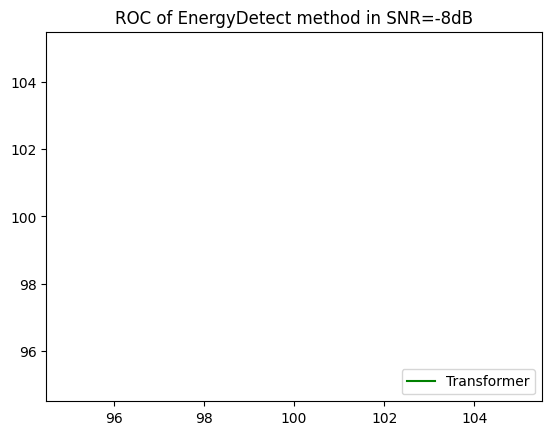

ROC in Excel saved to: Saved_Models/EnergyDetect/RandMod/-8dBVol10_260511_14_13/ROC_SNR-8.xlsx
ROC in Lists saved to: Saved_Models/EnergyDetect/RandMod/-8dBVol10_260511_14_13/EnergyDetectROC.pth


/tmp/ipykernel_2444337/2615564119.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load(datadir)


[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]] [2, 3, 2, 2, 6, 6, 2, 2, 3, 2, 3, 2, 2, 6, 2, 2, 3, 2, 2, 6]
model watermark 260511_14_19
Models saved to dir:
 Saved_Models/EnergyDetect/RandMod/-10dBVol10_260511_14_19/
threshold: 100.0
thresh: 100.0 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 101.0
thresh: 101.0 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 102.0
thresh: 102.0 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 103.0
thresh: 103.0 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 104.0
thresh: 104

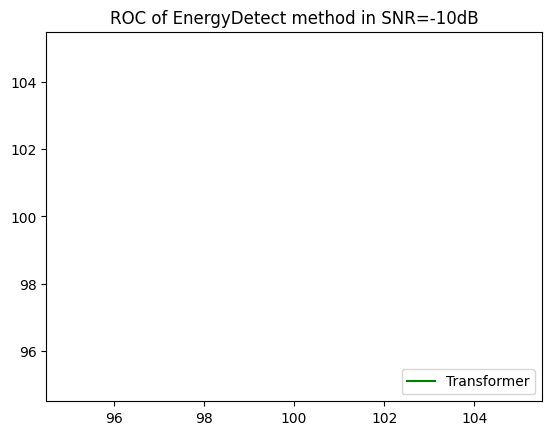

ROC in Excel saved to: Saved_Models/EnergyDetect/RandMod/-10dBVol10_260511_14_19/ROC_SNR-10.xlsx
ROC in Lists saved to: Saved_Models/EnergyDetect/RandMod/-10dBVol10_260511_14_19/EnergyDetectROC.pth


/tmp/ipykernel_2444337/2615564119.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load(datadir)


[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]] [2, 3, 2, 2, 6, 6, 2, 2, 3, 2, 3, 2, 2, 6, 2, 2, 3, 2, 2, 6]
model watermark 260511_14_22
Models saved to dir:
 Saved_Models/EnergyDetect/RandMod/-12dBVol10_260511_14_22/
threshold: 170.0
thresh: 170.0 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 171.3
thresh: 171.3 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 172.6
thresh: 172.6 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 173.9
thresh: 173.9 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 175.2
thresh: 175

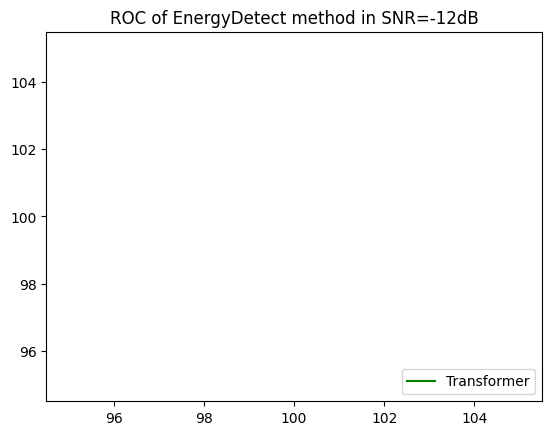

ROC in Excel saved to: Saved_Models/EnergyDetect/RandMod/-12dBVol10_260511_14_22/ROC_SNR-12.xlsx
ROC in Lists saved to: Saved_Models/EnergyDetect/RandMod/-12dBVol10_260511_14_22/EnergyDetectROC.pth


/tmp/ipykernel_2444337/2615564119.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load(datadir)


[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]] [2, 3, 2, 2, 6, 6, 2, 2, 3, 2, 3, 2, 2, 6, 2, 2, 3, 2, 2, 6]
model watermark 260511_14_24
Models saved to dir:
 Saved_Models/EnergyDetect/RandMod/-14dBVol10_260511_14_24/
threshold: 300.0
thresh: 300.0 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 301.6
thresh: 301.6 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 303.2
thresh: 303.2 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 304.8
thresh: 304.8 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 306.4
thresh: 306

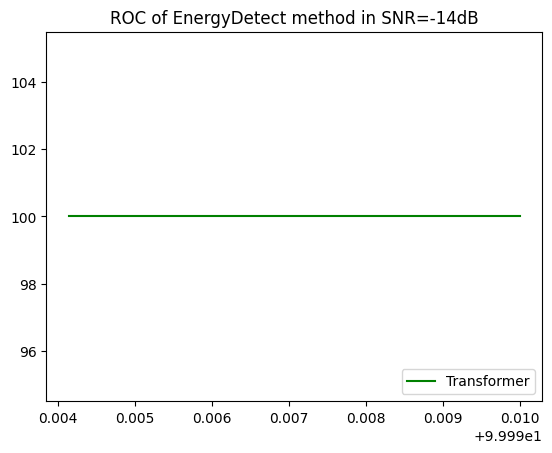

ROC in Excel saved to: Saved_Models/EnergyDetect/RandMod/-14dBVol10_260511_14_24/ROC_SNR-14.xlsx
ROC in Lists saved to: Saved_Models/EnergyDetect/RandMod/-14dBVol10_260511_14_24/EnergyDetectROC.pth


/tmp/ipykernel_2444337/2615564119.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load(datadir)


[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]] [2, 3, 2, 2, 6, 6, 2, 2, 3, 2, 3, 2, 2, 6, 2, 2, 3, 2, 2, 6]
model watermark 260511_14_31
Models saved to dir:
 Saved_Models/EnergyDetect/RandMod/-16dBVol10_260511_14_31/
threshold: 450.0
thresh: 450.0 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 452.5
thresh: 452.5 accuracy: 50.0 PD: 100.0 PFA: 100.0
threshold: 455.0
thresh: 455.0 accuracy: 50.0009765625 PD: 100.0 PFA: 99.998046875
threshold: 457.5
thresh: 457.5 accuracy: 50.0009765625 PD: 100.0 PFA: 99.998046

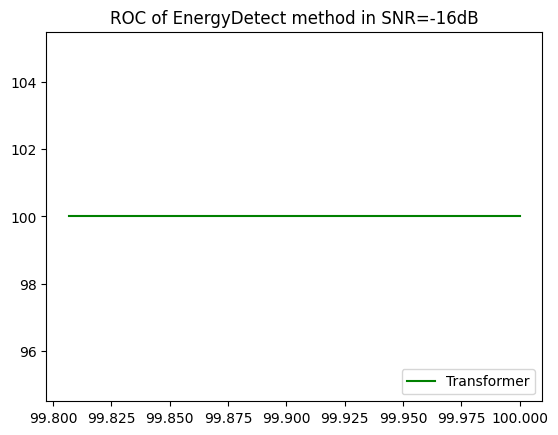

ROC in Excel saved to: Saved_Models/EnergyDetect/RandMod/-16dBVol10_260511_14_31/ROC_SNR-16.xlsx
ROC in Lists saved to: Saved_Models/EnergyDetect/RandMod/-16dBVol10_260511_14_31/EnergyDetectROC.pth


In [3]:
for snr in [0,2,4,6,8,10,12,14,16]: #: #[12, 8 ]: #[12, 8, 14, 16, 20]
    roc_dots = 100
    volum = 10
    SNR= -1*snr 
    nepoch = 1
    datadir_te = '/mnt/110e4fe8-b416-4f34-8f8b-66a64d07a44f/anjani/partial/PartialObservation-main/final/PartialObservation/260103_001533/Data_SNR'+str(SNR)+'vol20'+'.pth' # RandMod: revision dataset, PU mod varying (testing data only)
    
    # datadir_tr = datadir_te
    datadir = 'RefinedNewData/SNRs/230404_01_04/Data_SNR'+str(SNR)+'vol'+str(volum)+'.pth'
    datadir = datadir_te
    # stage_dir='/SNRs/'#default for naming and directory
    stage_dir='/RandMod/' # PU mod varying (testing data only)

    data_dict = torch.load(datadir)
    data_dict.keys()

    db = data_dict['training data list']
    label_list = data_dict['training label list']
    db_te = data_dict['testing data list']
    label_list_te = data_dict['testing label list']

    # Create models ==================================================================================================
    per_class_filter = 8
    #fms = 16 #size of final conv feature map
    shared_layers = 1
    class_dir=[[0, 3, 4, 19], [0, 1, 10, 4, 19], [1, 10, 4, 19, 5, 13], [1, 10, 2, 11, 14, 5, 13], [2, 11, 14, 5, 13, 6, 15, 17], [3, 4, 19, 7, 12, 18], [4, 19, 7, 12, 18, 8, 16], [4, 19, 5, 13, 8, 16], [5, 13, 8, 16, 9], [5, 13, 6, 15, 17, 9]]

    tol_list = []
    for classi in class_dir:
        tol_list += classi
    tol_list = list( set(tol_list) )
    tol_list.sort()

    print(class_dir)
    print(tol_list)

    # get coef 
    idx_list, coef_list = Dis_analysis(class_dir, tol_list)
    print(idx_list, coef_list)


    db_tr_list = []
    for idx in range(len(class_dir)):# train datasets are more complex
        db_tr_list.append(NodeDatasetMaker( db, label_list, idx, class_dir, transforms.Compose([ ]) ))
    db_te_1 = TotalDatasetMaker( db_te, label_list_te, transforms.Compose([ ]) )

    train_loader_list = []
    for idx in range(len(class_dir)):# trainloaders are more complex
        train_loader_list.append(DataLoader(db_tr_list[idx], batch_size=200, shuffle=True, num_workers=4, pin_memory=True))
    # tol_train_loader = DataLoader(tol_trainsets, batch_size=100, shuffle=False, num_workers=0, pin_memory=True)
    tol_test_loader = DataLoader(db_te_1, batch_size=1024, shuffle=False, num_workers=4, pin_memory=True)

    now=datetime.datetime.now(TMZ) #time watermark
    time_watermark = now.strftime('%y%m%d_%H_%M')
    print('model watermark',time_watermark)
    address_model = 'Saved_Models/EnergyDetect'+stage_dir+str(SNR)+'dBVol'+str(volum)+'_'+time_watermark+'/' #root dir for saved models
    #child dir nbamed by time_watermark
    setDir(address_model)
   
    print('Models saved to dir:\n', address_model)
    name0 = 'EnergyDetect'+'_SNR'+str(SNR)+'vol'+str(volum) # common part of DNN node names


    # ROC  ==================================================================================================
    '''ROC module of current standalone model, saved in pd2 and pfa2'''
    # net_list = Split_MDLT(net_list, net_tol, idx_list, coef_list,  shared_layers, class_dir) # if merged net better, do this before ROC
    pd2= []
    pfa2 = []
    Acc2 = []

    for thresh_val in thresh_dict[SNR]:  
        print('threshold:', thresh_val)
        thresh_list = [thresh_val]*len(class_dir)
        testing=energy_detection_coop(thresh_list, class_dir, coef_list, tol_test_loader)
        print('thresh:', thresh_val, 'accuracy:',testing[0], 'PD:',testing[2], 'PFA:',testing[3])

        pd2.append(testing[2])
        pfa2.append(testing[3])
        Acc2.append(testing[0])

    plt.title("ROC of EnergyDetect"+ " method in SNR="+str(SNR)+"dB")
    l2, = plt.plot(pfa2, pd2, color='green', label='Transformer')
    plt.legend(loc='lower right')
    plt.show()

    dfroc = pd.DataFrame() # save statics to excel
    # df1['acc_old'] = xx
    dfroc['PFA'] = pfa2
    dfroc['PD'] = pd2
    dfroc['Acc'] = Acc2
    with pd.ExcelWriter(address_model + "ROC_SNR"+str(SNR)+".xlsx", mode='w') as writer:  #mode was 'a'
      dfroc.to_excel(writer, sheet_name='EnergyDetect')
    print('ROC in Excel saved to:', address_model + "ROC_SNR"+str(SNR)+".xlsx")

    ROC_dict = {
        'pd':pd2,
        'pfa':pfa2,
        'Acc':Acc2
    }
    torch.save(ROC_dict, address_model+'EnergyDetect'+'ROC.pth')
    print('ROC in Lists saved to:', address_model+'EnergyDetect'+'ROC.pth')


In [6]:
pip install openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
